<a href="https://colab.research.google.com/github/datadigger01/AppStatMat/blob/main/Mahalnobis_distance_ex1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Install a Korean font in Colab
!sudo apt-get install -y fonts-nanum
!sudo fc-cache -fv
!rm ~/.cache/matplotlib -rf

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
fonts-nanum is already the newest version (20200506-1).
0 upgraded, 0 newly installed, 0 to remove and 38 not upgraded.
/usr/share/fonts: caching, new cache contents: 0 fonts, 1 dirs
/usr/share/fonts/truetype: caching, new cache contents: 0 fonts, 3 dirs
/usr/share/fonts/truetype/humor-sans: caching, new cache contents: 1 fonts, 0 dirs
/usr/share/fonts/truetype/liberation: caching, new cache contents: 16 fonts, 0 dirs
/usr/share/fonts/truetype/nanum: caching, new cache contents: 12 fonts, 0 dirs
/usr/local/share/fonts: caching, new cache contents: 0 fonts, 0 dirs
/root/.local/share/fonts: skipping, no such directory
/root/.fonts: skipping, no such directory
/usr/share/fonts/truetype: skipping, looped directory detected
/usr/share/fonts/truetype/humor-sans: skipping, looped directory detected
/usr/share/fonts/truetype/liberation: skipping, looped directory detected
/usr/share/fonts/truetype/

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False # Allow negative signs in the plot

공분산(Σ⁻¹ 변환):
 [[ 0.621 -0.31 ]
 [-0.31   0.673]]

=== Outlier 거리 비교 ===
           X1        X2  Euclid_original  Mahalanobis  Euclid_transformed
37   2.627347  3.789692         4.568801     2.768740            1.790141
89  -1.599313  2.247587         2.771550     2.702415            2.641381
104 -3.355095  2.093491         3.985660     3.803038            3.687930
110 -1.514510 -4.155222         4.456752     3.031777            2.345923
131  4.694077  3.245374         5.656697     3.333194            2.020675
142 -1.232087 -3.992756         4.210704     2.942536            2.345078
210 -3.765104 -1.282677         4.028994     2.662493            1.987564
239 -4.562502 -2.979184         5.499391     3.266858            2.020160
272  3.590624  2.463644         4.304476     2.538221            1.541516
300  4.000000  2.000000         4.420912     2.735377            1.842425
301 -4.000000  2.000000         4.506822     4.217357            4.059085
302  4.000000 -2.000000         4.437775

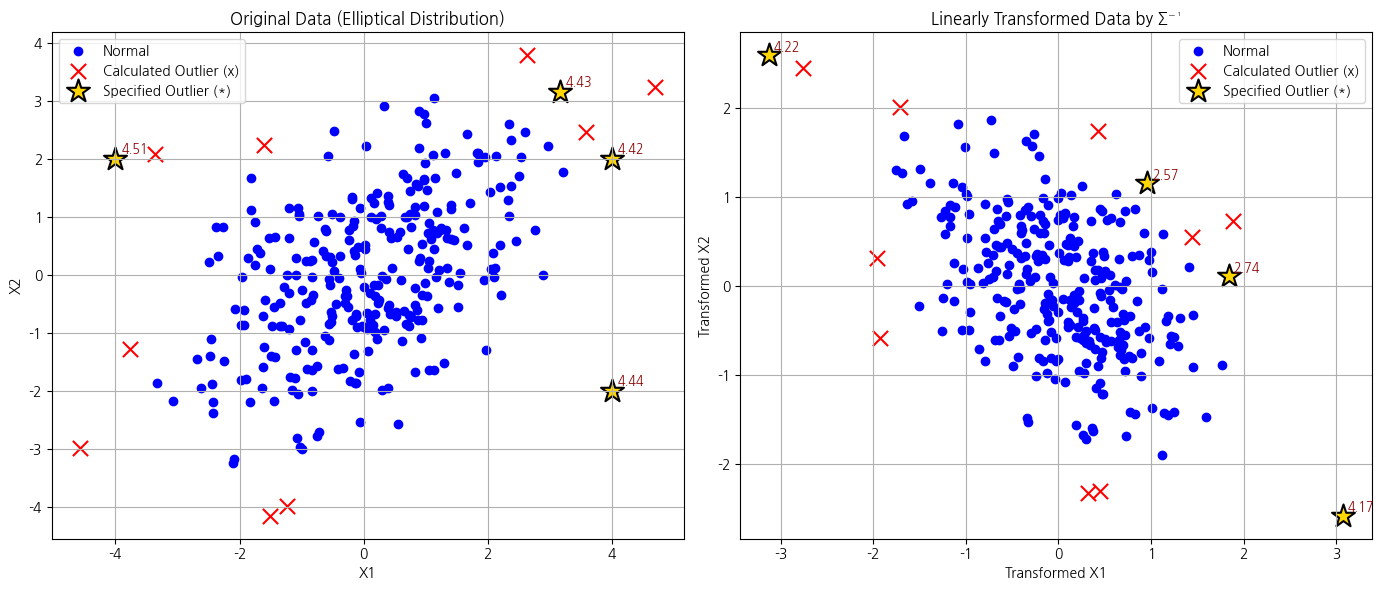

In [ ]:
from scipy.stats import chi2
from scipy.spatial import distance
from scipy.linalg import fractional_matrix_power
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# =======================================================
# 1. 데이터 생성
# =======================================================
np.random.seed(42)
mean = [0, 0]
cov = [[2, 1],
       [1, 2]]

# 정상 데이터 + 이상치
data = np.random.multivariate_normal(mean, cov, size=300)
outliers = np.array([[4, 2], [-4, 2], [4, -2], [np.sqrt(10), np.sqrt(10)]])
df_total = pd.DataFrame(np.vstack([data, outliers]), columns=['X1', 'X2'])

# =======================================================
# 2. Mahalanobis 거리 계산
# =======================================================
mu = df_total.mean().values
cov_matrix = np.cov(df_total.T)
inv_cov_matrix = np.linalg.inv(cov_matrix)

mahal_dist = df_total.apply(lambda x: distance.mahalanobis(x, mu, inv_cov_matrix), axis=1)
df_total['Mahalanobis'] = mahal_dist

# 임계값 (95%)
threshold = np.sqrt(chi2.ppf(0.95, df=2))
df_total['Outlier'] = df_total['Mahalanobis'] > threshold

# Identify the specific outliers from the 'outliers' array
specified_outlier_indices = df_total[df_total[['X1', 'X2']].apply(tuple, axis=1).isin([tuple(o) for o in outliers])].index
df_total['Specified_Outlier'] = False
df_total.loc[specified_outlier_indices, 'Specified_Outlier'] = True


# =======================================================
# 3. Σ⁻¹ 선형변환
# =======================================================
# 중심화
X_centered = df_total[['X1', 'X2']].values - mu

# Σ⁻¹를 이용한 선형 변환
X_transformed = X_centered @ inv_cov_matrix

# 변환된 데이터의 공분산 확인 (단위 행렬이 아님)
cov_transformed = np.cov(X_transformed.T)
print("공분산(Σ⁻¹ 변환):\n", np.round(cov_transformed, 3))

df_total['TX1'] = X_transformed[:, 0]
df_total['TX2'] = X_transformed[:, 1]

# =======================================================
# 4. Outlier 거리 비교
# =======================================================
# Calculate Euclid_original for the entire dataframe first
df_total['Euclid_original'] = np.linalg.norm(df_total[['X1', 'X2']].values - mu, axis=1)

outlier_df = df_total[df_total['Outlier']].copy()

# (1) 원공간 유클리드 거리 (already calculated for df_total)
# outlier_df['Euclid_original'] = np.linalg.norm(outlier_df[['X1', 'X2']].values - mu, axis=1)

# (2) 마할라노비스 거리 (이미 계산됨)
# outlier_df['Mahalanobis'] = outlier_df['Mahalanobis'] # Already in outlier_df

# (3) 변환공간 유클리드 거리 (Σ⁻¹ 공간) - 이것이 마할라노비스 거리와 같음
outlier_df['Euclid_transformed'] = np.linalg.norm(outlier_df[['TX1', 'TX2']].values, axis=1)


print("\n=== Outlier 거리 비교 ===")
print(outlier_df[['X1', 'X2', 'Euclid_original', 'Mahalanobis', 'Euclid_transformed']])

# =======================================================
# 5. 시각화
# =======================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# (1) 원공간
axes[0].scatter(df_total.loc[~df_total['Outlier'], 'X1'],
                df_total.loc[~df_total['Outlier'], 'X2'],
                c='blue', label='Normal')

# Plot calculated outliers (excluding the specified ones)
axes[0].scatter(df_total.loc[df_total['Outlier'] & ~df_total['Specified_Outlier'], 'X1'],
                df_total.loc[df_total['Outlier'] & ~df_total['Specified_Outlier'], 'X2'],
                c='red', marker='x', s=120, label='Calculated Outlier (x)')

# Plot the specified outliers with a star marker
axes[0].scatter(df_total.loc[df_total['Specified_Outlier'], 'X1'],
                df_total.loc[df_total['Specified_Outlier'], 'X2'],
                c='gold', marker='*', s=300, edgecolors='black', linewidth=1.5, label='Specified Outlier (*)')

# Add Euclidean distance labels for the specified outliers in the original space
for i, row in df_total[df_total['Specified_Outlier']].iterrows():
    axes[0].text(row['X1'] + 0.1, row['X2'] + 0.1,
                 f"{row['Euclid_original']:.2f}", color='darkred', fontsize=9)


axes[0].set_title("Original Data (Elliptical Distribution)")
axes[0].set_xlabel("X1")
axes[0].set_ylabel("X2")
axes[0].grid(True)
axes[0].legend()

# (2) Σ⁻¹ 변환공간
axes[1].scatter(df_total.loc[~df_total['Outlier'], 'TX1'],
                df_total.loc[~df_total['Outlier'], 'TX2'],
                c='blue', label='Normal')

# Plot calculated outliers in transformed space (excluding the specified ones)
axes[1].scatter(df_total.loc[df_total['Outlier'] & ~df_total['Specified_Outlier'], 'TX1'],
                df_total.loc[df_total['Outlier'] & ~df_total['Specified_Outlier'], 'TX2'],
                c='red', marker='x', s=120, label='Calculated Outlier (x)')

# Plot the specified outliers in transformed space with a star marker
axes[1].scatter(df_total.loc[df_total['Specified_Outlier'], 'TX1'],
                df_total.loc[df_total['Specified_Outlier'], 'TX2'],
                c='gold', marker='*', s=300, edgecolors='black', linewidth=1.5, label='Specified Outlier (*)')

# Add Mahalanobis distance labels for the specified outliers in the transformed space
for i, row in df_total[df_total['Specified_Outlier']].iterrows():
    axes[1].text(row['TX1'] + 0.05, row['TX2'] + 0.05,
                 f"{row['Mahalanobis']:.2f}", color='darkred', fontsize=9)

axes[1].set_title("Linearly Transformed Data by Σ⁻¹")
axes[1].set_xlabel("Transformed X1")
axes[1].set_ylabel("Transformed X2")
axes[1].grid(True)
axes[1].legend()

plt.tight_layout()
plt.show()